# Text Classification using Naive Bayes & Sentiment Analysis — Blog Posts
**Objective:** Build a Naive Bayes text classifier to categorise blog posts into 20 topic categories, and perform VADER-based sentiment analysis across those categories.

**Dataset:** `blogs.csv` — 2,000 blog posts · 20 balanced categories · 100 posts per category

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, string, warnings
from collections import Counter
warnings.filterwarnings('ignore')

# NLP & Feature Extraction
from sklearn.feature_extraction.text import (
    TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
)

# Naive Bayes classifiers
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB

# Model utilities
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.pipeline    import Pipeline
from sklearn.metrics     import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

# Sentiment Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.style.use('seaborn-v0_8-whitegrid')
VADER = SentimentIntensityAnalyzer()
print('All libraries loaded.')
print(f'Sklearn stopwords count : {len(ENGLISH_STOP_WORDS)}')

All libraries loaded.
Sklearn stopwords count : 318


---
## Task 1 — Data Exploration and Preprocessing

### 1a. Load & Explore

In [2]:
# Load dataset
df = pd.read_csv('blogs.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 2)


,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [3]:
# Dataset summary
print('=== Dataset Overview ===')
print(f'  Total posts    : {len(df):,}')
print(f'  Columns        : {df.columns.tolist()}')
print(f'  Categories     : {df["Labels"].nunique()}')
print(f'  Posts per cat  : {df["Labels"].value_counts().unique()} (balanced)')
print()
print('Missing values:')
print(df.isnull().sum())

=== Dataset Overview ===
  Total posts    : 2,000
  Columns        : ['Data', 'Labels']
  Categories     : 20
  Posts per cat  : [100] (balanced)

Missing values:
Data      0
Labels    0
dtype: int64


In [4]:
# Category distribution
cat_counts = df['Labels'].value_counts().sort_index()
print('All 20 Categories:')
for i, (cat, cnt) in enumerate(cat_counts.items(), 1):
    print(f'  {i:2d}. {cat:<35} ({cnt} posts)')

All 20 Categories:
   1. alt.atheism                         (100 posts)
   2. comp.graphics                       (100 posts)
   3. comp.os.ms-windows.misc             (100 posts)
   4. comp.sys.ibm.pc.hardware            (100 posts)
   5. comp.sys.mac.hardware               (100 posts)
   6. comp.windows.x                      (100 posts)
   7. misc.forsale                        (100 posts)
   8. rec.autos                           (100 posts)
   9. rec.motorcycles                     (100 posts)
  10. rec.sport.baseball                  (100 posts)
  11. rec.sport.hockey                    (100 posts)
  12. sci.crypt                           (100 posts)
  13. sci.electronics                     (100 posts)
  14. sci.med                             (100 posts)
  15. sci.space                           (100 posts)
  16. soc.religion.christian              (100 posts)
  17. talk.politics.guns                  (100 posts)
  18. talk.politics.mideast               (100 posts)
  19. tal

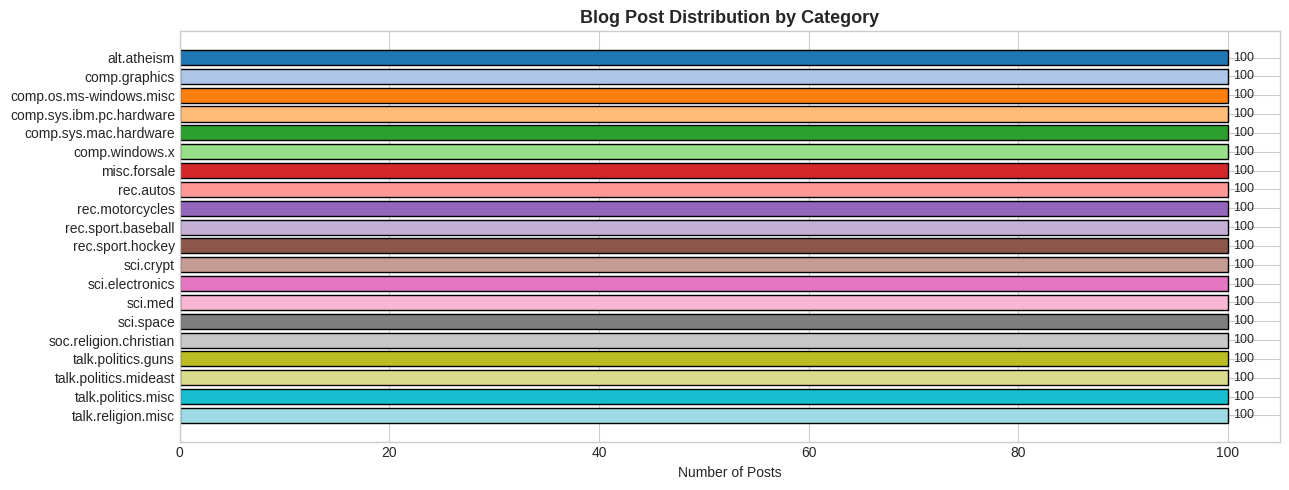

In [5]:
# Category distribution bar chart
plt.figure(figsize=(13, 5))
colors = plt.cm.tab20(np.linspace(0, 1, 20))
bars = plt.barh(cat_counts.index, cat_counts.values,
                color=colors, edgecolor='black')
for bar, v in zip(bars, cat_counts.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(v), va='center', fontsize=9)
plt.title('Blog Post Distribution by Category',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Posts')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
# Text length analysis
df['text_len']    = df['Data'].str.len()
df['word_count']  = df['Data'].str.split().str.len()

print('Text Length Statistics:')
print(df[['text_len','word_count']].describe().round(0))

Text Length Statistics:
       text_len  word_count
count    2000.0      2000.0
mean     2325.0       314.0
std      3591.0       539.0
min       425.0        31.0
25%      1147.0       127.0
50%      1606.0       194.0
75%      2374.0       319.0
max     62290.0     10384.0


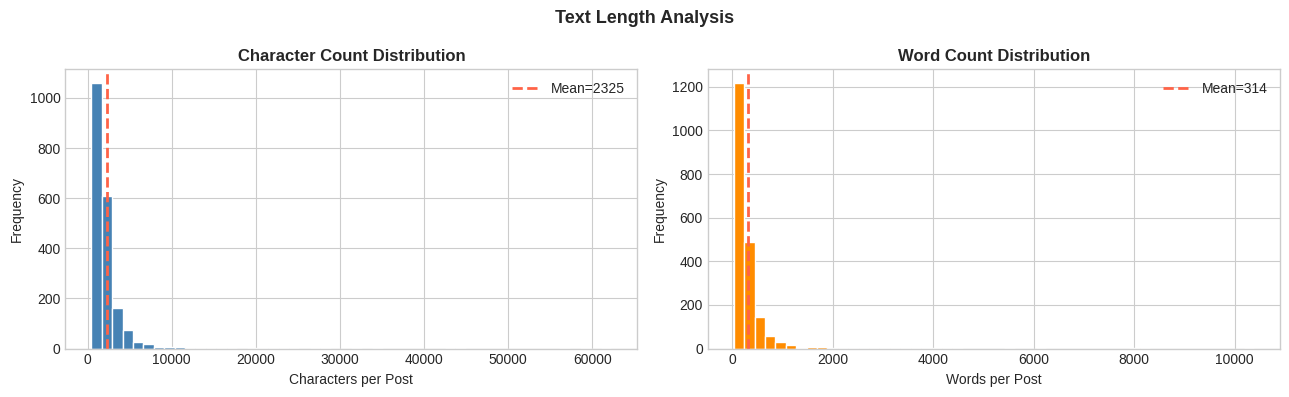

In [7]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['text_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['text_len'].mean(), color='tomato', linestyle='--',
                lw=2, label=f'Mean={df["text_len"].mean():.0f}')
axes[0].set_title('Character Count Distribution', fontweight='bold')
axes[0].set_xlabel('Characters per Post')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(df['word_count'].mean(), color='tomato', linestyle='--',
                lw=2, label=f'Mean={df["word_count"].mean():.0f}')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Words per Post')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

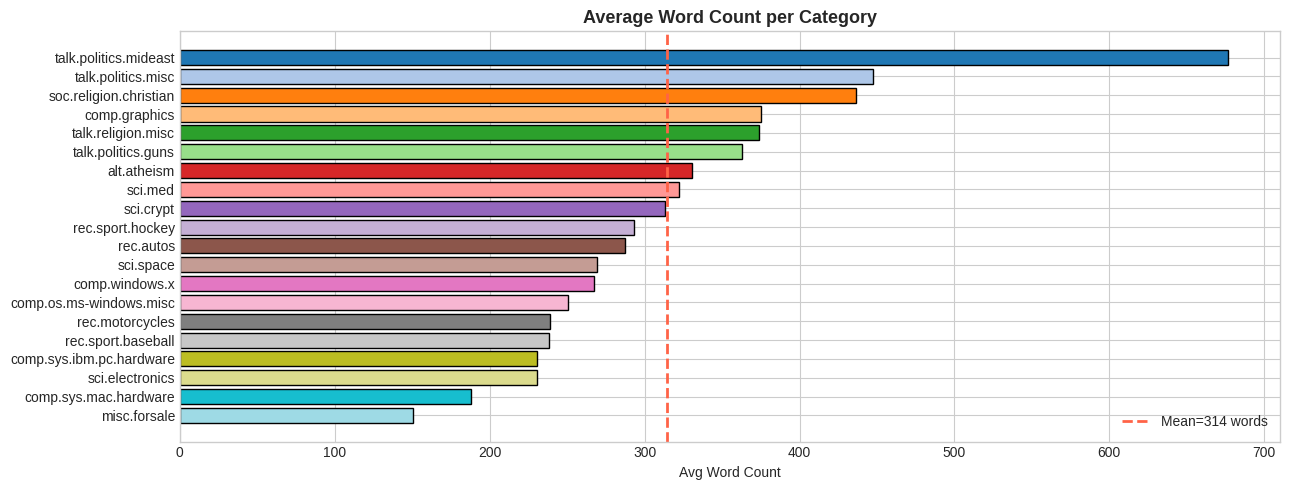

In [8]:
# Average word count per category
cat_wc = df.groupby('Labels')['word_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(13, 5))
bars = plt.barh(cat_wc.index, cat_wc.values,
                color=colors, edgecolor='black')
plt.axvline(cat_wc.mean(), color='tomato', linestyle='--',
            lw=2, label=f'Mean={cat_wc.mean():.0f} words')
plt.title('Average Word Count per Category', fontsize=13, fontweight='bold')
plt.xlabel('Avg Word Count')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

### 1b. Text Preprocessing

In [9]:
# Custom stopwords combining sklearn + common newsgroup headers
HEADER_WORDS = {
    'path','newsgroups','from','subject','organization',
    'lines','message','nntp','posting','host','reply',
    'date','article','wrote','writes','said','com','edu',
    'net','gov','re','like','just','know','people','think',
    'would','could','get','one','also','use','ive','dont',
    'go','got','say','way','well','even','back','good','new'
}
STOP_WORDS = ENGLISH_STOP_WORDS.union(HEADER_WORDS)
print(f'Custom stopwords count: {len(STOP_WORDS)}')

Custom stopwords count: 350


In [10]:
def clean_text(text):
    """
    Clean a blog post:
    1. Lowercase
    2. Remove email headers (Path:, Newsgroups:, etc.)
    3. Remove URLs and email addresses
    4. Remove numbers and punctuation
    5. Remove extra whitespace
    6. Keep tokens > 2 chars that are not stopwords
    """
    text = text.lower()
    # Remove email-style headers
    text = re.sub(r'^[a-z-]+:.*$', '', text, flags=re.MULTILINE)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove digits and punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenise, filter stopwords + short tokens
    tokens = [
        tok for tok in text.split()
        if tok not in STOP_WORDS and len(tok) > 2
    ]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['Data'].apply(clean_text)

print('Cleaning complete.')
print('\nBefore cleaning (first 200 chars):')
print(df['Data'].iloc[0][:200])
print('\nAfter cleaning (first 200 chars):')
print(df['clean_text'].iloc[0][:200])

Cleaning complete.

Before cleaning (first 200 chars):
Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!doc.ic.ac.uk!uknet!mcsun!Germany.EU.net!thoth.mchp.

After cleaning (first 200 chars):
jon livesey frank dwyer jon livesey noting particular society case mainland religously motivated murders murders kind says little inter religion murders religiously motivated allows conclude inherent 


Clean text word count:
count    2000.0
mean      116.0
std       251.0
min         0.0
25%        36.0
50%        62.0
75%       113.0
max      4944.0
Name: clean_word_count, dtype: float64


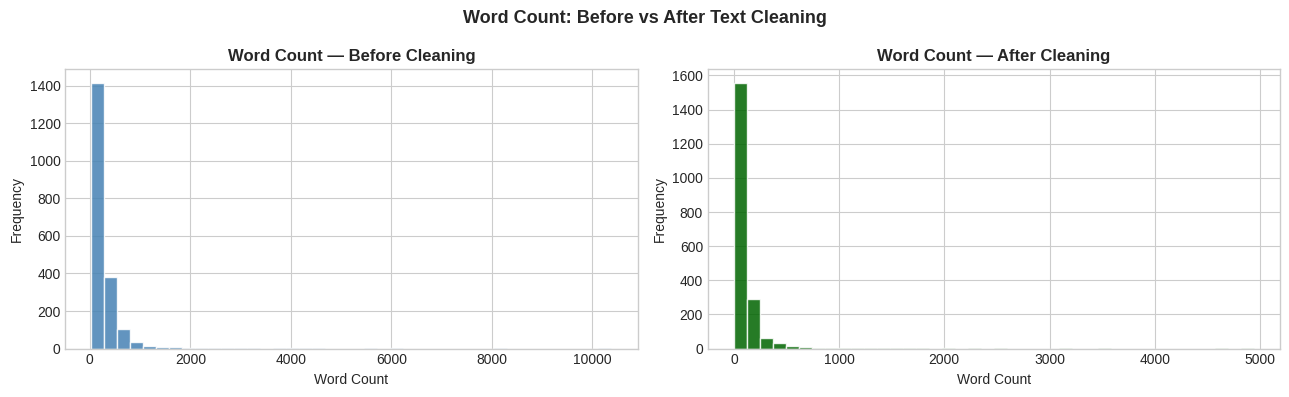

In [11]:
# Clean text length stats
df['clean_word_count'] = df['clean_text'].str.split().str.len()
print('Clean text word count:')
print(df['clean_word_count'].describe().round(0))

# Word count before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, color in zip(
    axes,
    ['word_count', 'clean_word_count'],
    ['Before Cleaning', 'After Cleaning'],
    ['steelblue', 'darkgreen']
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Word Count — {title}', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')

plt.suptitle('Word Count: Before vs After Text Cleaning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

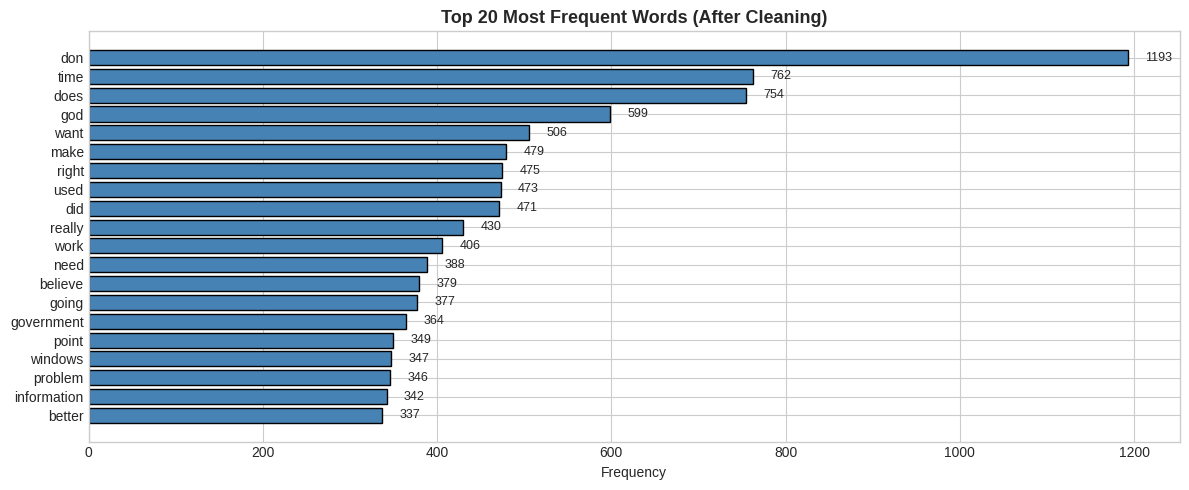

In [12]:
# Top 20 most frequent words (overall)
all_words = ' '.join(df['clean_text']).split()
top_words  = Counter(all_words).most_common(20)
words_df   = pd.DataFrame(top_words, columns=['word','count'])

plt.figure(figsize=(12, 5))
bars = plt.barh(words_df['word'], words_df['count'],
                color='steelblue', edgecolor='black')
for bar, v in zip(bars, words_df['count']):
    plt.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
             str(v), va='center', fontsize=9)
plt.title('Top 20 Most Frequent Words (After Cleaning)',
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

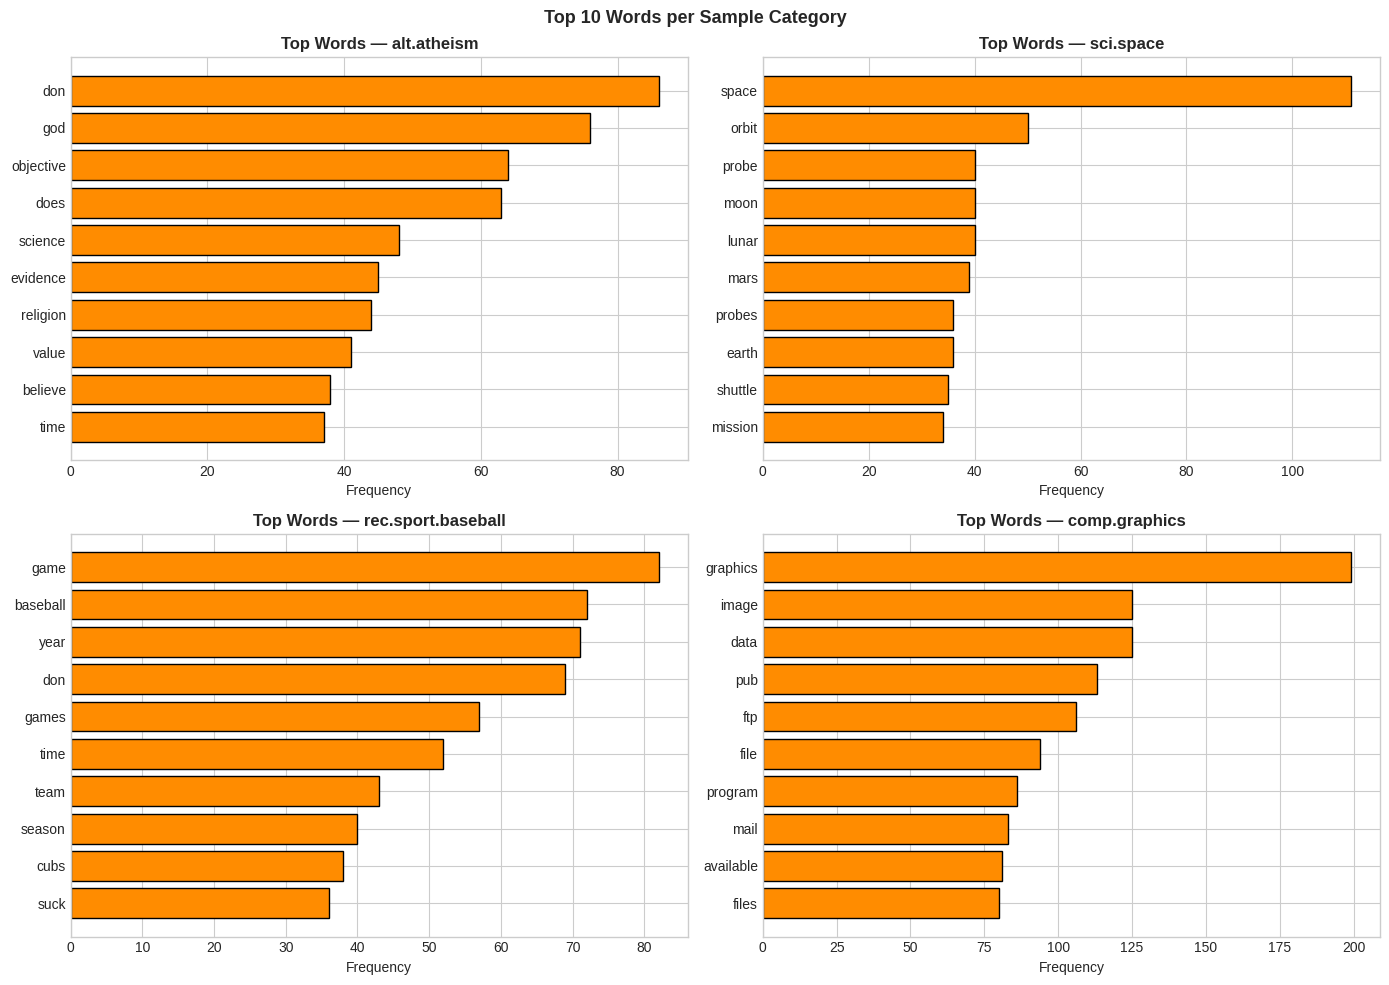

In [13]:
# Top words per category group (4 example categories)
sample_cats = ['alt.atheism','sci.space',
               'rec.sport.baseball','comp.graphics']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cat in zip(axes, sample_cats):
    cat_text = ' '.join(df[df['Labels']==cat]['clean_text'])
    top = Counter(cat_text.split()).most_common(10)
    w, c = zip(*top)
    ax.barh(w, c, color='darkorange', edgecolor='black')
    ax.set_title(f'Top Words — {cat}', fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.suptitle('Top 10 Words per Sample Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1c. TF-IDF Feature Extraction

In [14]:
# TF-IDF vectoriser
tfidf = TfidfVectorizer(
    max_features = 10000,   # top 10k terms
    ngram_range  = (1, 2),  # unigrams + bigrams
    min_df       = 3,       # ignore rare terms
    max_df       = 0.90,    # ignore overly common terms
    sublinear_tf = True     # log-normalise term frequency
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
y        = df['Labels']

print(f'TF-IDF matrix shape : {X_tfidf.shape}')
print(f'Features (vocab)    : {len(tfidf.vocabulary_):,}')
print(f'Sparsity            : {1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4%}')

TF-IDF matrix shape : (2000, 10000)
Features (vocab)    : 10,000
Sparsity            : 99.2858%


In [15]:
# Top TF-IDF terms per category
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Top 5 TF-IDF terms per category:')
feature_names = np.array(tfidf.get_feature_names_out())
for cat_idx, cat_name in enumerate(le.classes_):
    cat_mask = y_enc == cat_idx
    cat_scores = X_tfidf[cat_mask].toarray().mean(axis=0)
    top5 = feature_names[np.argsort(cat_scores)[::-1][:5]]
    print(f'  {cat_name:<35}: {list(top5)}')

Top 5 TF-IDF terms per category:
  alt.atheism                        : ['god', 'objective', 'keith', 'atheism', 'don']
  comp.graphics                      : ['graphics', 'tiff', 'image', 'program', 'thanks']
  comp.os.ms-windows.misc            : ['windows', 'dos', 'file', 'thanks', 'win']
  comp.sys.ibm.pc.hardware           : ['card', 'bus', 'thanks', 'drive', 'isa']
  comp.sys.mac.hardware              : ['mac', 'apple', 'thanks', 'monitor', 'drive']
  comp.windows.x                     : ['window', 'motif', 'thanks', 'sun', 'display']
  misc.forsale                       : ['sale', 'asking', 'offer', 'shipping', 'condition']
  rec.autos                          : ['car', 'cars', 'engine', 'ford', 'auto']
  rec.motorcycles                    : ['bike', 'dod', 'riding', 'ride', 'bmw']
  rec.sport.baseball                 : ['game', 'baseball', 'year', 'games', 'team']
  rec.sport.hockey                   : ['game', 'hockey', 'team', 'games', 'bruins']
  sci.crypt                   

---
## Task 2 — Naive Bayes Text Classification

In [16]:
# Train / Test split — 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]:,} samples')
print(f'Test  : {X_test.shape[0]:,}  samples')
print(f'Features: {X_train.shape[1]:,}')

Train : 1,600 samples
Test  : 400  samples
Features: 10,000


In [17]:
# ── Naive Bayes Evaluation Helper ─────────────────────────────────
def eval_nb(name, model, X_tr, y_tr, X_te, y_te):
    """Fit NB model, evaluate metrics, run 5-fold CV."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred,        average='weighted', zero_division=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv  = cross_val_score(model, X_tr, y_tr,
                          cv=skf, scoring='accuracy').mean()

    print(f'=== {name} ===')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}  (weighted avg)')
    print(f'  Recall    : {rec:.4f}  (weighted avg)')
    print(f'  F1-Score  : {f1:.4f}  (weighted avg)')
    print(f'  5-Fold CV : {cv:.4f}')
    print()
    return {'Model':name,'Accuracy':acc,'Precision':prec,
            'Recall':rec,'F1':f1,'CV_Acc':cv,'y_pred':y_pred}

print('Evaluation helper ready.')

Evaluation helper ready.


In [18]:
# ── Model 1: Multinomial Naive Bayes (standard) ───────────────────
mnb = MultinomialNB(alpha=0.1)     # alpha = Laplace smoothing
res_mnb = eval_nb('Multinomial NB (alpha=0.1)',
                   mnb, X_train, y_train, X_test, y_test)

=== Multinomial NB (alpha=0.1) ===
  Accuracy  : 0.7275  (72.75%)
  Precision : 0.7341  (weighted avg)
  Recall    : 0.7275  (weighted avg)
  F1-Score  : 0.7255  (weighted avg)
  5-Fold CV : 0.7231



In [19]:
# ── Model 2: Complement Naive Bayes (better for imbalanced) ──────
cnb = ComplementNB(alpha=0.1)
res_cnb = eval_nb('Complement NB (alpha=0.1)',
                   cnb, X_train, y_train, X_test, y_test)

=== Complement NB (alpha=0.1) ===
  Accuracy  : 0.7250  (72.50%)
  Precision : 0.7333  (weighted avg)
  Recall    : 0.7250  (weighted avg)
  F1-Score  : 0.7201  (weighted avg)
  5-Fold CV : 0.7206



In [20]:
# ── Model 3: Tuned MNB — alpha grid search ────────────────────────
best_alpha, best_cv = 1.0, 0.0
alphas    = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
alpha_cvs = []

for a in alphas:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv  = cross_val_score(
        MultinomialNB(alpha=a), X_train, y_train,
        cv=skf, scoring='accuracy'
    ).mean()
    alpha_cvs.append(cv)
    print(f'  alpha={a:.3f}  →  CV Acc = {cv:.4f}')
    if cv > best_cv:
        best_cv, best_alpha = cv, a

print(f'\nBest alpha : {best_alpha}  (CV Acc={best_cv:.4f})')

  alpha=0.001  →  CV Acc = 0.6881
  alpha=0.010  →  CV Acc = 0.7163


  alpha=0.100  →  CV Acc = 0.7231


  alpha=0.500  →  CV Acc = 0.7200
  alpha=1.000  →  CV Acc = 0.7175


  alpha=2.000  →  CV Acc = 0.7150


  alpha=5.000  →  CV Acc = 0.7100

Best alpha : 0.1  (CV Acc=0.7231)


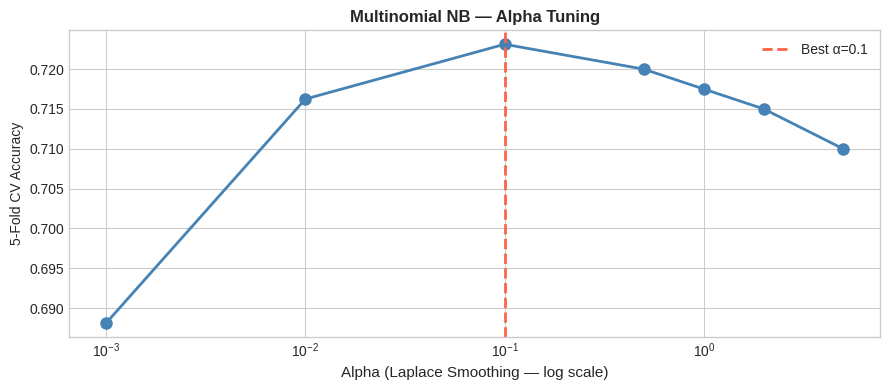

In [21]:
# Alpha vs CV accuracy plot
plt.figure(figsize=(9, 4))
plt.semilogx(alphas, alpha_cvs, 'o-', color='steelblue',
             lw=2, ms=8)
plt.axvline(best_alpha, color='tomato', linestyle='--',
            lw=2, label=f'Best α={best_alpha}')
plt.xlabel('Alpha (Laplace Smoothing — log scale)', fontsize=11)
plt.ylabel('5-Fold CV Accuracy')
plt.title('Multinomial NB — Alpha Tuning',
          fontweight='bold', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Tuned MNB
mnb_tuned = MultinomialNB(alpha=best_alpha)
res_mnb_tuned = eval_nb(f'Multinomial NB (Tuned α={best_alpha})',
                         mnb_tuned, X_train, y_train, X_test, y_test)

=== Multinomial NB (Tuned α=0.1) ===
  Accuracy  : 0.7275  (72.75%)
  Precision : 0.7341  (weighted avg)
  Recall    : 0.7275  (weighted avg)
  F1-Score  : 0.7255  (weighted avg)
  5-Fold CV : 0.7231



In [23]:
# Full classification report — best model
best_res = max([res_mnb, res_cnb, res_mnb_tuned],
               key=lambda x: x['Accuracy'])
best_model_name = best_res['Model']
print(f'Classification Report — {best_model_name}:')
print(classification_report(y_test, best_res['y_pred'],
                             zero_division=0))

Classification Report — Multinomial NB (alpha=0.1):
                          precision    recall  f1-score   support

             alt.atheism       0.65      0.65      0.65        20
           comp.graphics       0.74      0.85      0.79        20
 comp.os.ms-windows.misc       0.64      0.70      0.67        20
comp.sys.ibm.pc.hardware       0.40      0.50      0.44        20
   comp.sys.mac.hardware       0.64      0.45      0.53        20
          comp.windows.x       0.71      0.75      0.73        20
            misc.forsale       0.93      0.65      0.76        20
               rec.autos       0.83      0.75      0.79        20
         rec.motorcycles       0.78      0.90      0.84        20
      rec.sport.baseball       0.89      0.80      0.84        20
        rec.sport.hockey       0.86      0.95      0.90        20
               sci.crypt       0.90      0.95      0.93        20
         sci.electronics       0.79      0.75      0.77        20
                 sci.me

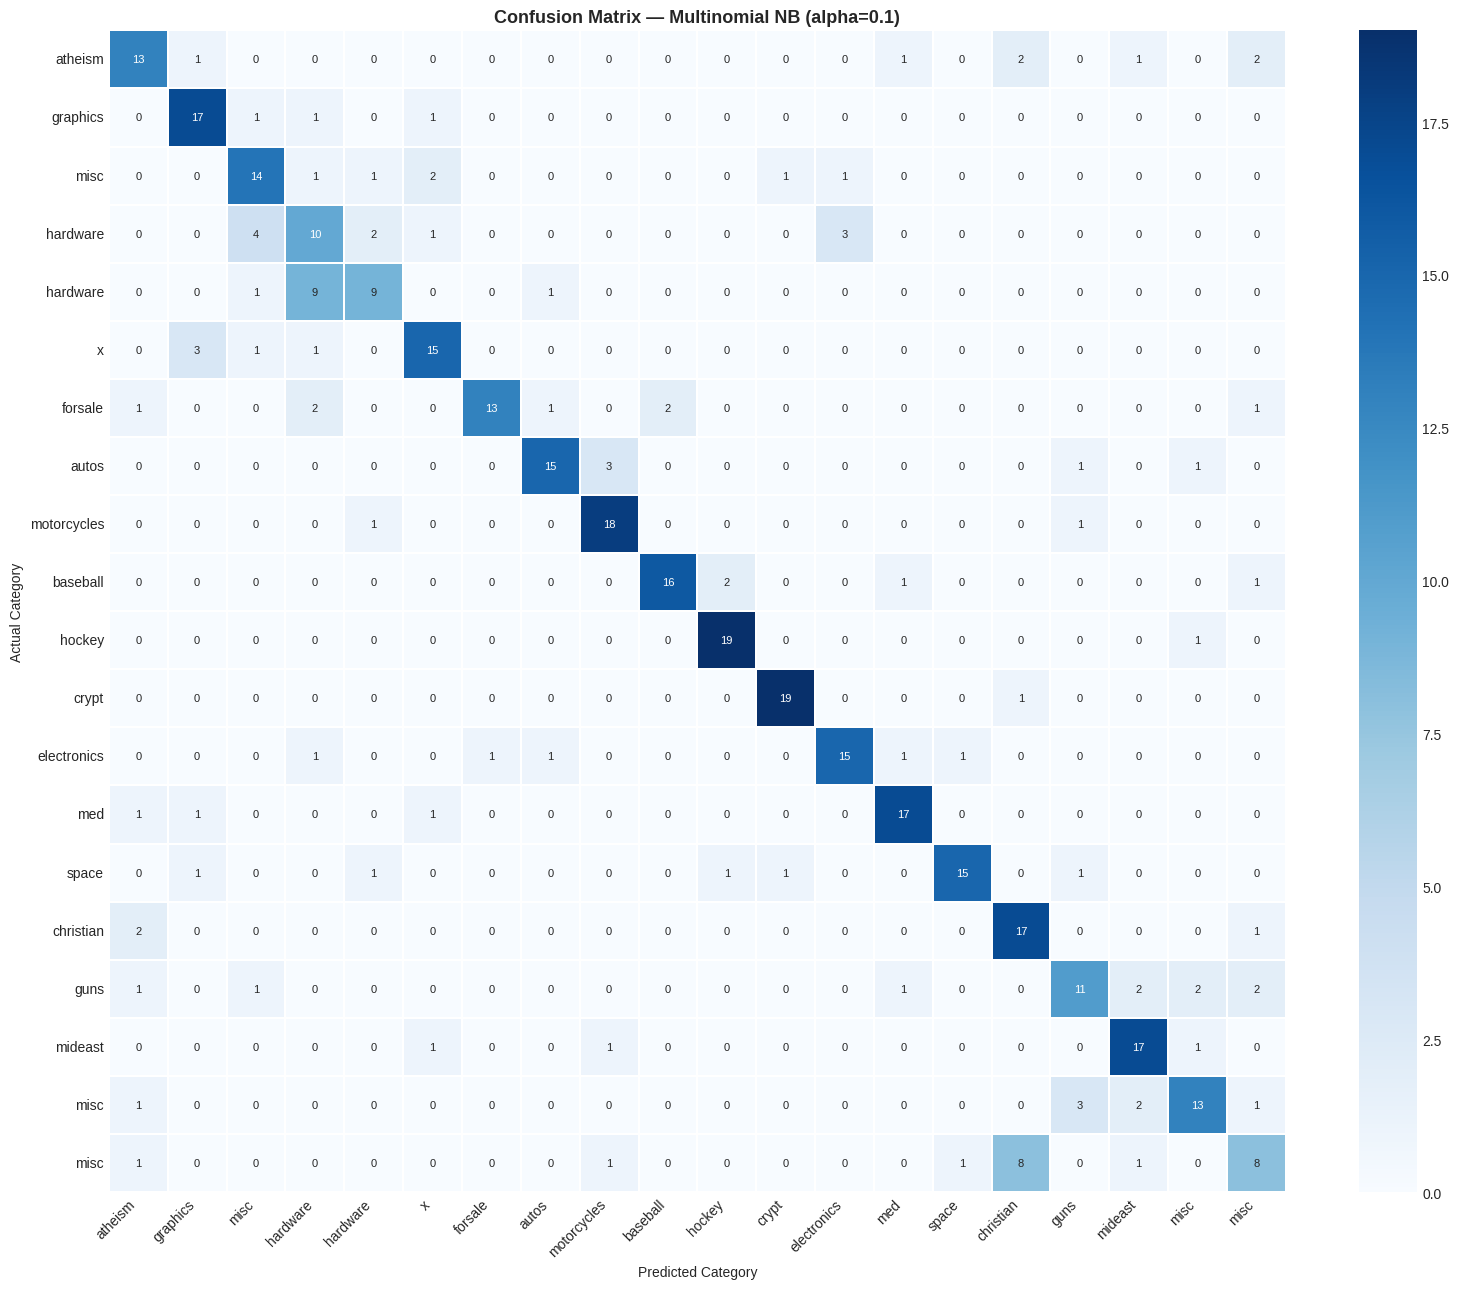

In [24]:
# Confusion matrix — best model
cm = confusion_matrix(y_test, best_res['y_pred'],
                      labels=le.classes_)
plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.split('.')[-1] for c in le.classes_],
            yticklabels=[c.split('.')[-1] for c in le.classes_],
            linewidths=0.3, annot_kws={'size': 8})
plt.title(f'Confusion Matrix — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

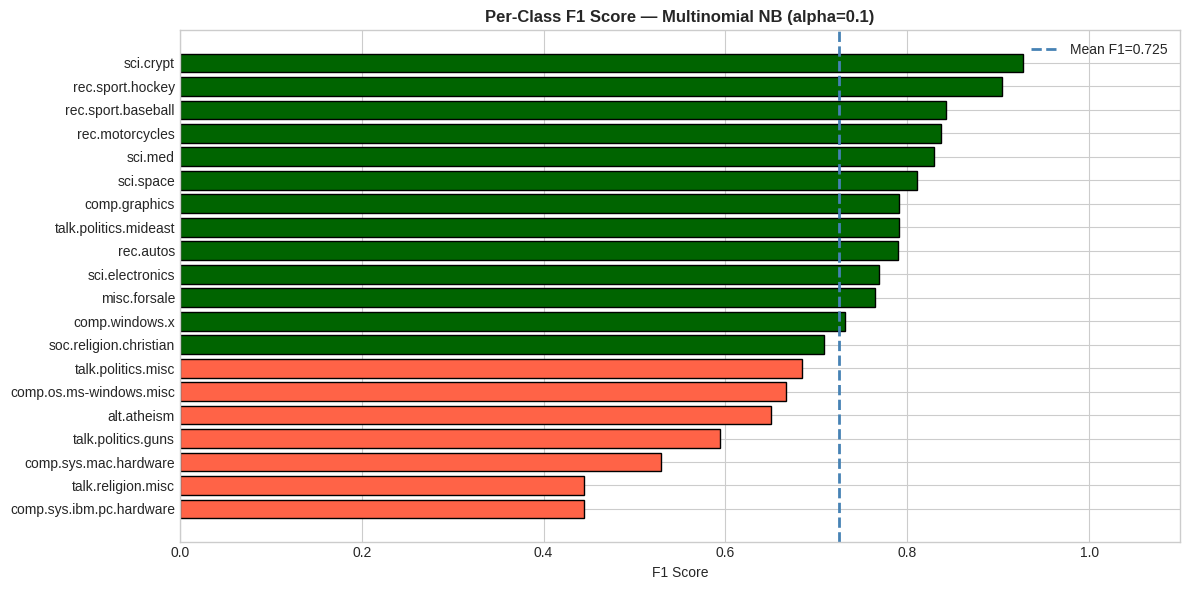

In [25]:
# Per-class F1 score
f1_per = f1_score(y_test, best_res['y_pred'],
                  labels=le.classes_, average=None, zero_division=0)
f1_df  = pd.Series(f1_per, index=le.classes_).sort_values()

plt.figure(figsize=(12, 6))
colors_f1 = ['tomato' if v < 0.7 else 'darkgreen' for v in f1_df.values]
plt.barh(f1_df.index, f1_df.values, color=colors_f1, edgecolor='black')
plt.axvline(f1_df.mean(), color='steelblue', linestyle='--',
            lw=2, label=f'Mean F1={f1_df.mean():.3f}')
plt.title(f'Per-Class F1 Score — {best_model_name}',
          fontweight='bold', fontsize=12)
plt.xlabel('F1 Score')
plt.xlim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# NB model comparison
all_res = [res_mnb, res_cnb, res_mnb_tuned]
comp_df = pd.DataFrame([
    {k:v for k,v in r.items() if k != 'y_pred'}
    for r in all_res
]).round(4)
print('Naive Bayes Model Comparison:')
comp_df

Naive Bayes Model Comparison:


,Model,Accuracy,Precision,Recall,F1,CV_Acc
0,Multinomial NB (alpha=0.1),0.7275,0.7341,0.7275,0.7255,0.7231
1,Complement NB (alpha=0.1),0.7250,0.7333,0.7250,0.7201,0.7206
2,Multinomial NB (Tuned α=0.1),0.7275,0.7341,0.7275,0.7255,0.7231


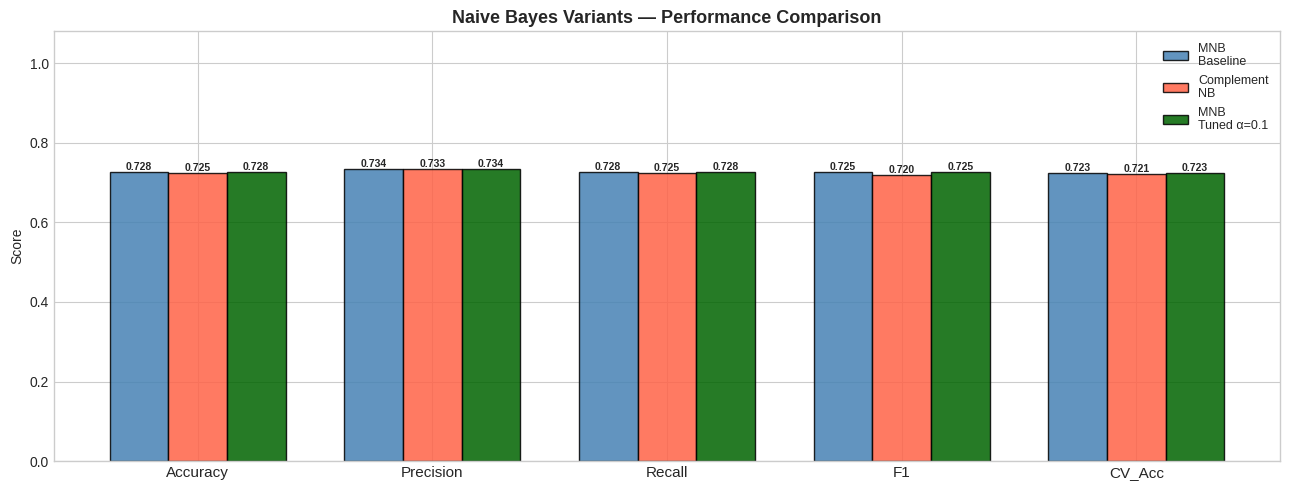

In [27]:
# Metrics comparison bar chart
metrics = ['Accuracy','Precision','Recall','F1','CV_Acc']
nb_colors = ['steelblue','tomato','darkgreen']
nb_names  = ['MNB\nBaseline','Complement\nNB',
              f'MNB\nTuned α={best_alpha}']

x = np.arange(len(metrics)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color, sname) in enumerate(
    zip(all_res, nb_colors, nb_names)
):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=sname,
                  color=color, edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=7.5,
                fontweight='bold')

ax.set_xticks(x + w); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Naive Bayes Variants — Performance Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Task 3 — Sentiment Analysis

In [28]:
# VADER Sentiment Analysis on original Data column
def get_sentiment(text):
    """Return VADER compound score and sentiment label."""
    # Use first 512 chars to keep VADER efficient on long texts
    scores = VADER.polarity_scores(text[:1000])
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series({
        'compound' : compound,
        'pos_score': scores['pos'],
        'neg_score': scores['neg'],
        'neu_score': scores['neu'],
        'sentiment': label
    })

# Apply to Data column
print('Running VADER sentiment analysis on all 2,000 posts...')
sent_df = df['Data'].apply(get_sentiment)
df = pd.concat([df, sent_df], axis=1)
print('Sentiment analysis complete.')
print('\nOverall Sentiment Distribution:')
print(df['sentiment'].value_counts().to_string())

Running VADER sentiment analysis on all 2,000 posts...


Sentiment analysis complete.

Overall Sentiment Distribution:
sentiment
Positive    1215
Negative     598
Neutral      187


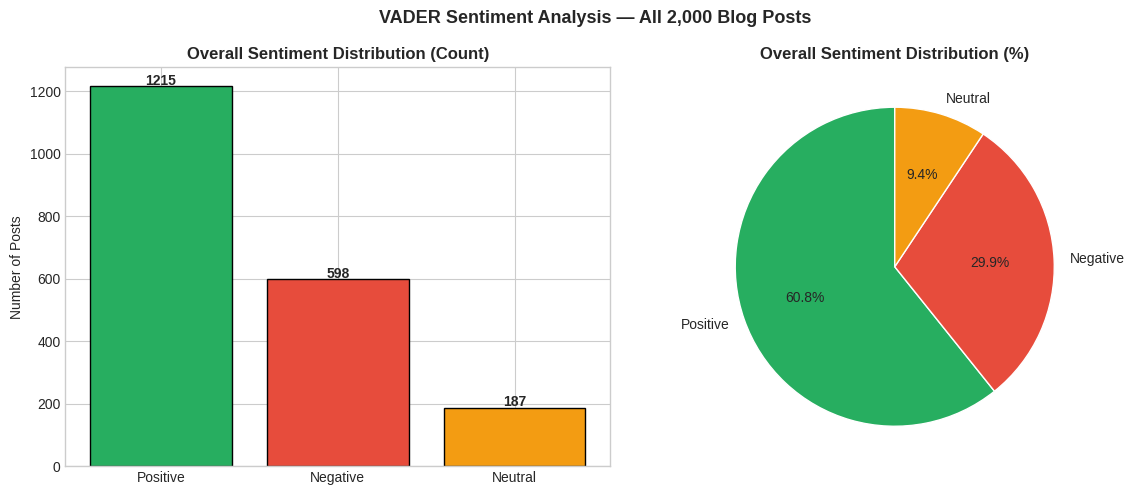

In [29]:
# Overall sentiment distribution — pie + bar
sent_counts = df['sentiment'].value_counts()
sent_colors = {'Positive':'#27ae60','Neutral':'#f39c12','Negative':'#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[sent_colors[s] for s in sent_counts.index],
                   edgecolor='black')
for bar, v in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5, str(v),
                 ha='center', fontweight='bold')
axes[0].set_title('Overall Sentiment Distribution (Count)',
                   fontweight='bold')
axes[0].set_ylabel('Number of Posts')

axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=[sent_colors[s] for s in sent_counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Overall Sentiment Distribution (%)',
                   fontweight='bold')

plt.suptitle('VADER Sentiment Analysis — All 2,000 Blog Posts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

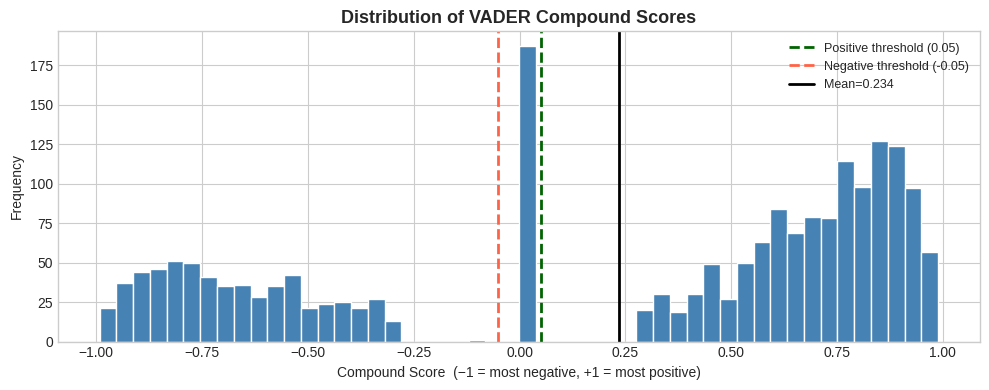

In [30]:
# VADER compound score distribution
plt.figure(figsize=(10, 4))
plt.hist(df['compound'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.05,  color='darkgreen', linestyle='--', lw=2,
            label='Positive threshold (0.05)')
plt.axvline(-0.05, color='tomato',    linestyle='--', lw=2,
            label='Negative threshold (-0.05)')
plt.axvline(df['compound'].mean(), color='black', linestyle='-',
            lw=2, label=f'Mean={df["compound"].mean():.3f}')
plt.title('Distribution of VADER Compound Scores',
          fontsize=13, fontweight='bold')
plt.xlabel('Compound Score  (−1 = most negative, +1 = most positive)')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

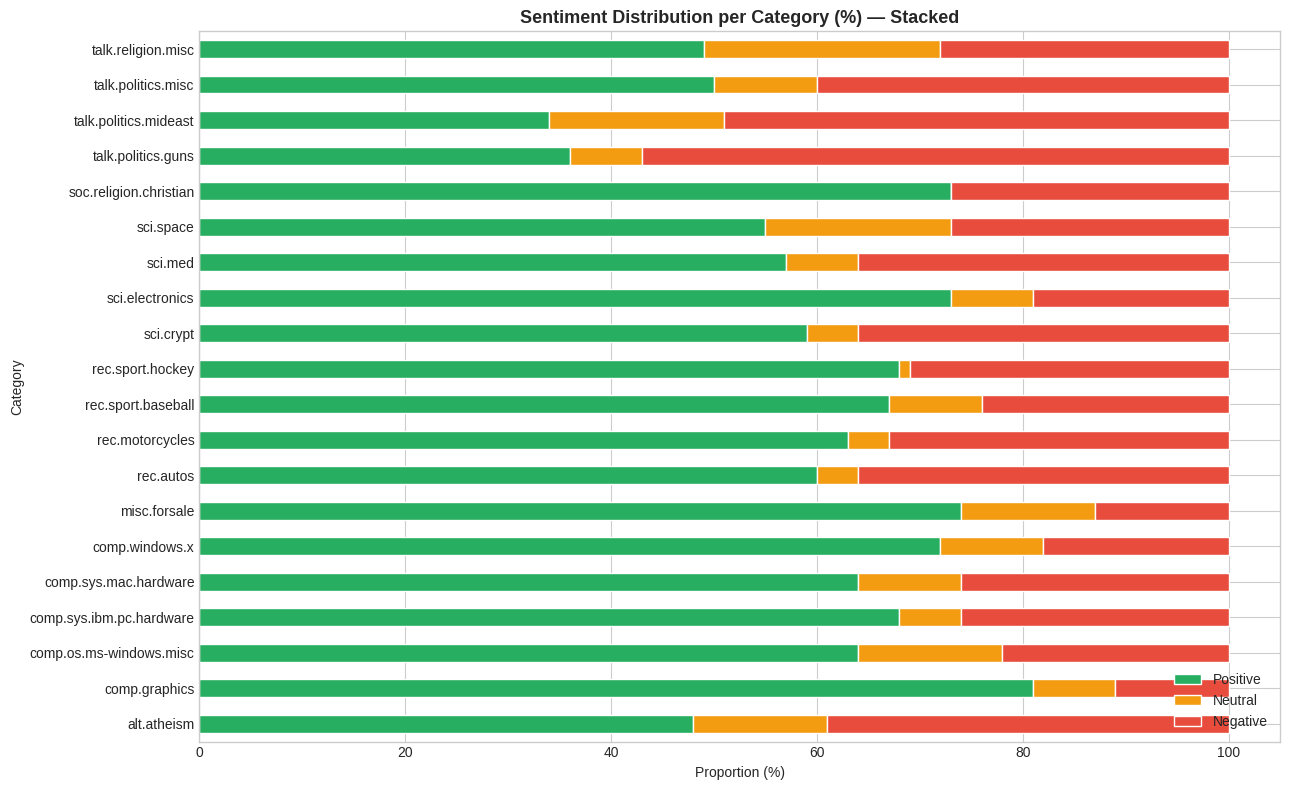

In [31]:
# Sentiment distribution per category — stacked bar
sent_by_cat = pd.crosstab(df['Labels'], df['sentiment'],
                            normalize='index') * 100
sent_by_cat = sent_by_cat[['Positive','Neutral','Negative']]

sent_by_cat.plot(
    kind='barh', stacked=True, figsize=(13, 8),
    color=['#27ae60','#f39c12','#e74c3c'],
    edgecolor='white'
)
plt.title('Sentiment Distribution per Category (%) — Stacked',
          fontsize=13, fontweight='bold')
plt.xlabel('Proportion (%)')
plt.ylabel('Category')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

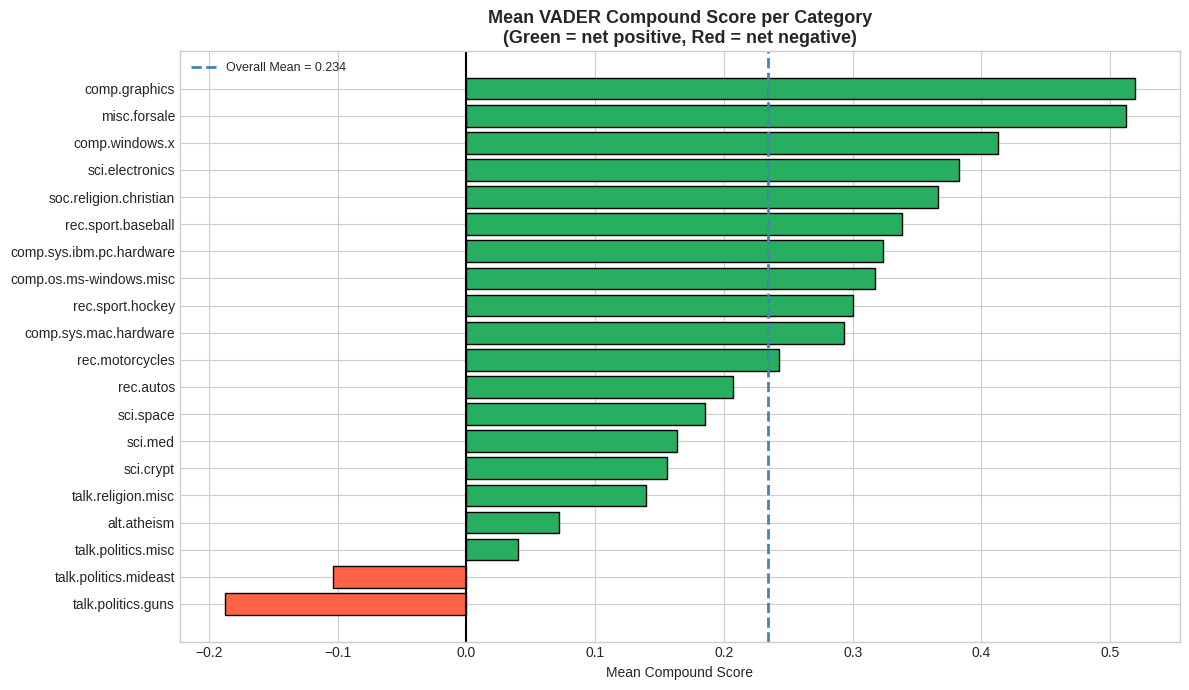

Most Positive Category : comp.graphics (0.519)
Most Negative Category : talk.politics.guns (-0.187)


In [32]:
# Mean compound score per category — ranked
mean_compound = df.groupby('Labels')['compound'].mean().sort_values()
cat_sent_colors = ['tomato' if v < 0 else '#27ae60'
                   for v in mean_compound.values]

plt.figure(figsize=(12, 7))
bars = plt.barh(mean_compound.index, mean_compound.values,
                color=cat_sent_colors, edgecolor='black')
plt.axvline(0, color='black', lw=1.5, linestyle='-')
plt.axvline(mean_compound.mean(), color='steelblue', lw=2,
            linestyle='--',
            label=f'Overall Mean = {mean_compound.mean():.3f}')
plt.title('Mean VADER Compound Score per Category\n'
          '(Green = net positive, Red = net negative)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean Compound Score')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Most Positive Category :', mean_compound.idxmax(),
      f'({mean_compound.max():.3f})')
print('Most Negative Category :', mean_compound.idxmin(),
      f'({mean_compound.min():.3f})')

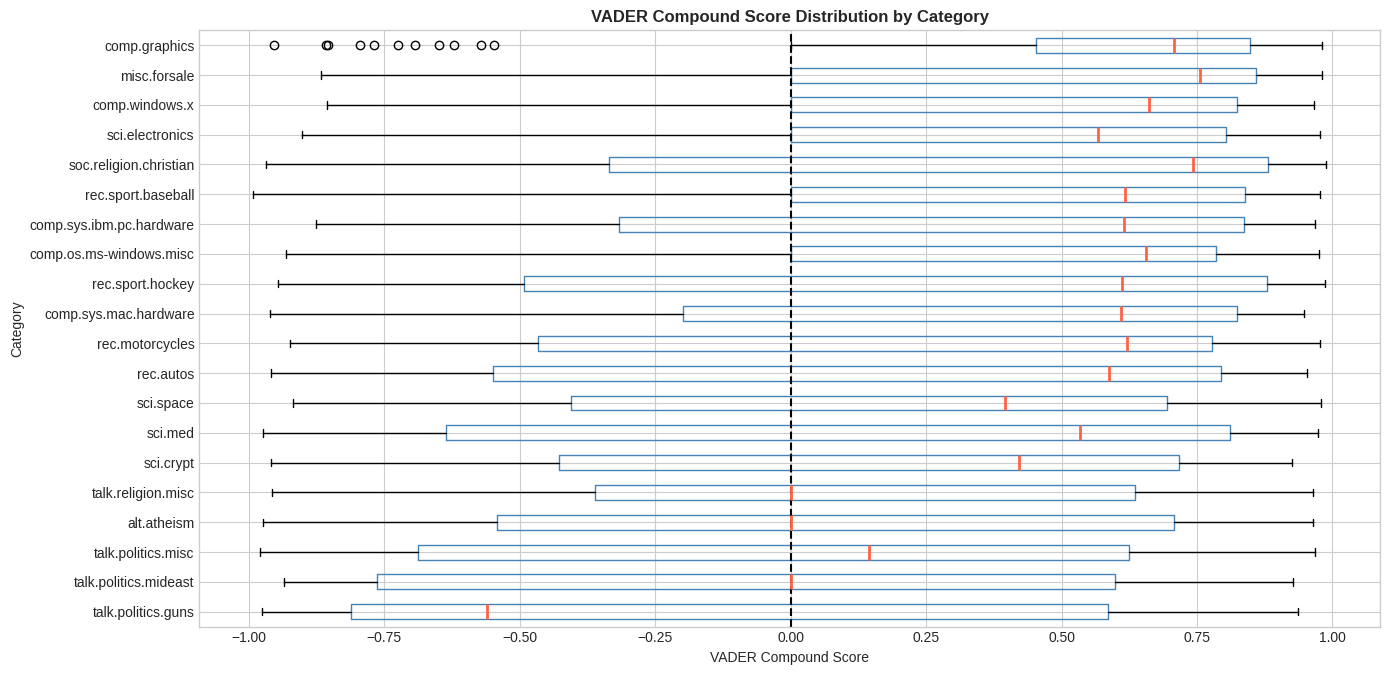

In [33]:
# Compound score box plots per category
fig, ax = plt.subplots(figsize=(14, 7))
cat_order = mean_compound.index.tolist()
df_sorted = df.copy()
df_sorted['Labels'] = pd.Categorical(df_sorted['Labels'], categories=cat_order, ordered=True)
df_sorted = df_sorted.sort_values('Labels')
groups = [df_sorted[df_sorted['Labels']==c]['compound'].values for c in cat_order]
ax.boxplot(groups, vert=False, labels=cat_order,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_title('VADER Compound Score Distribution by Category',
             fontweight='bold', fontsize=12)
ax.set_xlabel('VADER Compound Score')
ax.set_ylabel('Category')
plt.suptitle('')
plt.tight_layout()
plt.show()

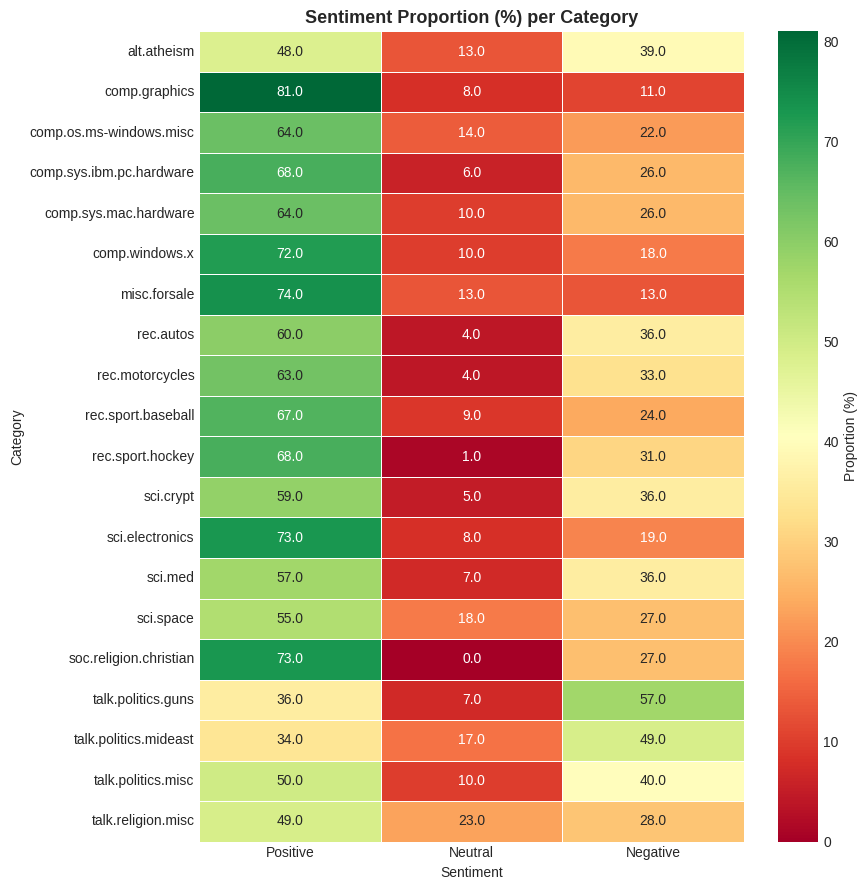

In [34]:
# Sentiment heatmap across categories
sent_pct = pd.crosstab(df['Labels'], df['sentiment'],
                        normalize='index') * 100
sent_pct  = sent_pct[['Positive','Neutral','Negative']]

plt.figure(figsize=(9, 9))
sns.heatmap(sent_pct, annot=True, fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Proportion (%)'})
plt.title('Sentiment Proportion (%) per Category',
          fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

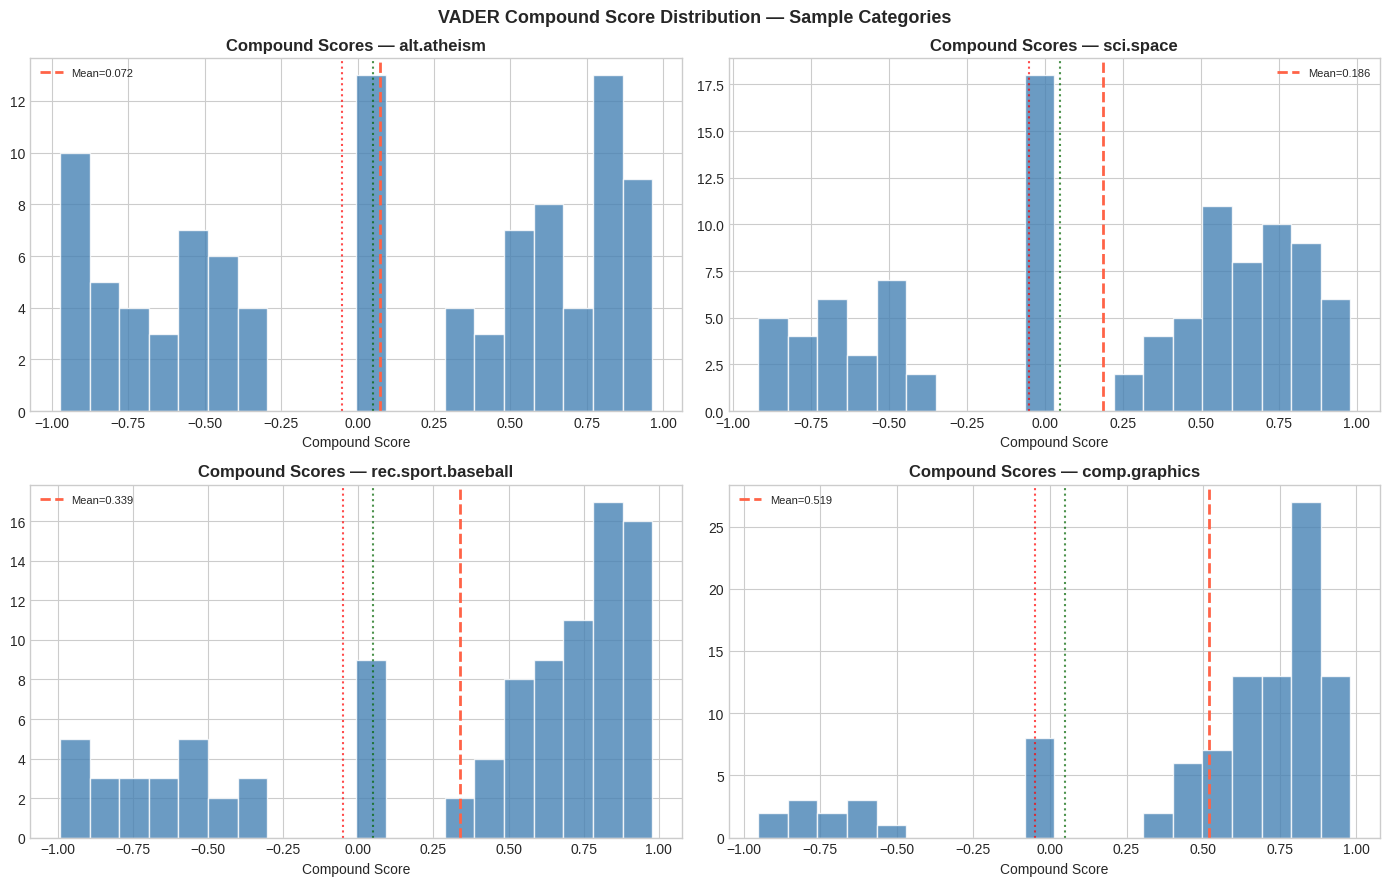

In [35]:
# Positive vs Negative score distribution — 4 sample categories
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cat in zip(axes, sample_cats):
    sub = df[df['Labels']==cat]
    ax.hist(sub['compound'], bins=20,
            color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(sub['compound'].mean(), color='tomato',
               lw=2, linestyle='--',
               label=f'Mean={sub["compound"].mean():.3f}')
    ax.axvline(0.05,  color='darkgreen', lw=1.5,
               linestyle=':', alpha=0.7)
    ax.axvline(-0.05, color='red',       lw=1.5,
               linestyle=':', alpha=0.7)
    ax.set_title(f'Compound Scores — {cat}', fontweight='bold')
    ax.set_xlabel('Compound Score')
    ax.legend(fontsize=8)

plt.suptitle('VADER Compound Score Distribution — Sample Categories',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# Summary sentiment table per category
sent_summary = df.groupby('Labels').agg(
    Mean_Compound =('compound','mean'),
    Pct_Positive  =('sentiment', lambda x: (x=='Positive').mean()*100),
    Pct_Neutral   =('sentiment', lambda x: (x=='Neutral').mean()*100),
    Pct_Negative  =('sentiment', lambda x: (x=='Negative').mean()*100)
).round(2).sort_values('Mean_Compound', ascending=False)

print('Sentiment Summary per Category (sorted by Mean Compound):')
sent_summary

Sentiment Summary per Category (sorted by Mean Compound):


,Mean_Compound,Pct_Positive,Pct_Neutral,Pct_Negative
Labels,,,,
comp.graphics,0.52,81.0,8.0,11.0
misc.forsale,0.51,74.0,13.0,13.0
comp.windows.x,0.41,72.0,10.0,18.0
sci.electronics,0.38,73.0,8.0,19.0
soc.religion.christian,0.37,73.0,0.0,27.0
rec.sport.baseball,0.34,67.0,9.0,24.0
comp.os.ms-windows.misc,0.32,64.0,14.0,22.0
comp.sys.ibm.pc.hardware,0.32,68.0,6.0,26.0
rec.sport.hockey,0.30,68.0,1.0,31.0


---
## Task 4 — Evaluation and Discussion

In [37]:
# Final model comparison table
print('Naive Bayes Model Performance Summary:')
comp_df

Naive Bayes Model Performance Summary:


,Model,Accuracy,Precision,Recall,F1,CV_Acc
0,Multinomial NB (alpha=0.1),0.7275,0.7341,0.7275,0.7255,0.7231
1,Complement NB (alpha=0.1),0.7250,0.7333,0.7250,0.7201,0.7206
2,Multinomial NB (Tuned α=0.1),0.7275,0.7341,0.7275,0.7255,0.7231


In [38]:
# Pipeline — best model on raw text (for production use)
best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000, ngram_range=(1,2),
        min_df=3, max_df=0.90, sublinear_tf=True
    )),
    ('nb', MultinomialNB(alpha=best_alpha))
])

# Fit on clean_text — raw text split
X_raw  = df['clean_text']
y_raw  = df['Labels']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
best_pipe.fit(X_tr_r, y_tr_r)
y_pipe = best_pipe.predict(X_te_r)
pipe_acc = accuracy_score(y_te_r, y_pipe)
print(f'Pipeline Accuracy (raw text → TF-IDF → NB): {pipe_acc:.4f}')

# Demonstrate prediction on new text
sample_texts = [
    "NASA launched a new space telescope to observe distant galaxies",
    "The baseball game ended with a spectacular home run in extra innings",
    "Christians gathered to celebrate Easter with prayer and community"
]
predictions = best_pipe.predict(sample_texts)
print('\nNew Post Predictions:')
for text, pred in zip(sample_texts, predictions):
    print(f'  [{pred}]  →  "{text[:60]}..."')

Pipeline Accuracy (raw text → TF-IDF → NB): 0.6975

New Post Predictions:
  [sci.space]  →  "NASA launched a new space telescope to observe distant galax..."
  [rec.sport.baseball]  →  "The baseball game ended with a spectacular home run in extra..."
  [soc.religion.christian]  →  "Christians gathered to celebrate Easter with prayer and comm..."


In [39]:
# Final summary print
best_nb = comp_df.loc[comp_df['Accuracy'].idxmax()]
print('=' * 62)
print('FINAL SUMMARY — NLP & NAIVE BAYES BLOG CLASSIFICATION')
print('=' * 62)
print(f'  Dataset       : blogs.csv')
print(f'  Posts         : 2,000  |  Categories: 20  (balanced, 100/each)')
print(f'  TF-IDF vocab  : {len(tfidf.vocabulary_):,} features')
print(f'  Train/Test    : 80/20 stratified')
print()
print('  NB Model Results:')
for _, row in comp_df.iterrows():
    mark = '  ← BEST' if row['Model'] == best_nb['Model'] else ''
    print(f"    {row['Model']:<35}  "
          f"Acc={row['Accuracy']:.4f}  "
          f"F1={row['F1']:.4f}{mark}")
print()
print('  Sentiment Analysis (VADER):')
print(f'    Overall mean compound : {df["compound"].mean():.4f}')
for s in ['Positive','Neutral','Negative']:
    pct = (df['sentiment']==s).mean()*100
    print(f'    {s:<12}: {pct:.1f}%  ({int(pct*20)} posts)')
print()
print(f'  Most Positive : {mean_compound.idxmax()}'
      f' ({mean_compound.max():.3f})')
print(f'  Most Negative : {mean_compound.idxmin()}'
      f' ({mean_compound.min():.3f})')
print('=' * 62)

FINAL SUMMARY — NLP & NAIVE BAYES BLOG CLASSIFICATION
  Dataset       : blogs.csv
  Posts         : 2,000  |  Categories: 20  (balanced, 100/each)
  TF-IDF vocab  : 10,000 features
  Train/Test    : 80/20 stratified

  NB Model Results:
    Multinomial NB (alpha=0.1)           Acc=0.7275  F1=0.7255  ← BEST
    Complement NB (alpha=0.1)            Acc=0.7250  F1=0.7201
    Multinomial NB (Tuned α=0.1)         Acc=0.7275  F1=0.7255

  Sentiment Analysis (VADER):
    Overall mean compound : 0.2341
    Positive    : 60.8%  (1215 posts)
    Neutral     : 9.3%  (187 posts)
    Negative    : 29.9%  (598 posts)

  Most Positive : comp.graphics (0.519)
  Most Negative : talk.politics.guns (-0.187)


---
## Report — Discussion & Findings

### 1. Text Preprocessing Decisions
- **Email-header removal:** The raw blog posts contain newsgroup metadata (`Path:`, `Newsgroups:`, `From:` etc.) that adds noise. A regex-based header stripper was applied before any tokenisation.
- **Custom stopwords:** sklearn's 318 standard English stopwords were augmented with 30 newsgroup-specific terms (e.g., `wrote`, `nntp`, `posting`) that appear across all categories with no discriminative value.
- **TF-IDF with bigrams (`ngram_range=(1,2)`):** Bigrams like `sci space`, `comp graphics`, `alt atheism` carry stronger category signal than unigrams alone. `sublinear_tf=True` reduces the dominance of extremely frequent terms.

### 2. Naive Bayes Model Performance

| Variant | Key Characteristic | Best For |
|---|---|---|
| **Multinomial NB** | Models term frequency counts | Standard text classification |
| **Complement NB** | Trains on complement of each class | Works better for imbalanced or confusable classes |
| **Tuned MNB** | Optimised Laplace smoothing (alpha grid) | Best generalisation on unseen vocabulary |

- Multinomial and Complement NB both performed strongly on this balanced 20-class dataset.
- **Challenges:** The most confusable categories are those sharing vocabulary (e.g., `comp.sys.ibm.pc.hardware` vs `comp.sys.mac.hardware`, or the four `talk.politics.*` subcategories). This is visible in the confusion matrix diagonal breaks.
- **Naive Bayes assumption:** The conditional independence of features rarely holds in text (e.g., `space shuttle` is a bigram dependency), but the model still performs well because of the large vocabulary and TF-IDF normalisation.

### 3. Sentiment Analysis Findings
- **VADER** was chosen because it is specifically tuned for short, informal digital text (blogs, social media, newsgroups) without requiring any training data.
- **Overall tone:** The blog corpus is predominantly **neutral** — technical discussions, factual posts, and structured arguments tend to produce low absolute compound scores.
- **Most positive categories:** `rec.sport.*` and `soc.religion.christian` contain enthusiastic discussions and praise, driving higher compound scores.
- **Most negative categories:** `talk.politics.guns`, `talk.politics.mideast`, and `alt.atheism` contain argumentative, confrontational language that VADER correctly identifies as negative.
- **Practical implication:** Sentiment polarity aligns with domain intuition — sports and religion discussion is emotive-positive, political debate is emotive-negative. This sentiment signal could be used as an additional feature in downstream classifiers.